In [142]:
import numpy as np 
import pandas as pd 
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.utils import shuffle
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder





pd.set_option('display.max_columns', None)

pd.set_option('display.max_rows', None)

# Ignorer tous les avertissements (utilisez avec précaution)
warnings.filterwarnings("ignore")

Le but de cette section est de predire la classe du contaminant sachant les autres variables explicatives (le glissement, la viteese et le CFL C).
On va commencer par une classification par un modèle d'apprentissage supervisé multimodale, univariée dans un premier temps (avec une vitesse fixée à 65km/h et 15% de freinage) puis multivarié en insérant un terme de dépendance du CFL C à Vitesse et G%.

Dans cette section on confond la neige fraiche sur glace et la neige fraiche sur béton, aussi la neige compctée sur glace et la neige compactée sur béton, car il s'agient du meme type, on peut se poser la question que si ces quatres types sont en réalité deux types, pourquoi dans la modelisation du CFL C on les a séparé ? 

Il faut comprendre tous d'abord comme surmentionné que le CFL C est un coeficient appartenant à l'intervalle 0, 1 et que 95% des observations sont inférieurs à 0.25 dans notre base de données, alors il faut etre vigilant lors de la modelisation en prenant en considération que chaque facteur qui peut se voir comme etant simple peut impacter le CFL C, c'est pourquoi on a decider d'etre le plus precis possible.



### Classification multimodale, univariée dans un premier temps (avec uniquement 65km/h et 15% de freinage)

Le fait de commencer par une analyse multimodale et univariée (vitesse 60km/h et 15%) et un travail commun dans le raisonnement physique, on va faire un retour à la table de donnée initiale pour extraire les données de vitesse 65 km/h et un taux de glissement de 15%, on va renettoyer cette partition en appliquant encore une fois des seuils de stabilité adaptées, mais en ajoutant un autre critère qui est la valeur absolue du glissement moyen - le glisssement consigne (15% en l'occurenrece) qui ne doit pas depassé 1,(c'est à dire que ce critère va accepté les valeurs du glissement moyen entre 14% et 16%), on supprime aussi les valeurs abérrantes. On applique alors un modele de classification sur cette base de donées et on visualise les resultats.

In [143]:
file_path = "DATASET_stage_total 2.0.xlsm"
sheet_name = 'TAB'
data = pd.read_excel(file_path, sheet_name=sheet_name)

In [144]:
column_to_keep = ['Vitesse', 'Glissement', 'Moyenne CFL F', 'Moyenne CFL C',
       'Moyenne G% [%]', 'Fv (kg)', 'ET G%', 'Ic G%', 'ET CFLF',
       'ET CFLC', 'Ic CFL C', 'ET Fv', 'Ic Fv', 'Contaminant']
def contaminant(x):
    if x in ["Neige fraiche (B)", "Neige fraiche (G)"]:
        return "Neige fraiche"
    elif x in ["N.C. (G)","N.C. (B)"]:
        return "N.C."
    else:
        return x

In [145]:
df = data[column_to_keep].copy()
df = df.dropna(axis = 0)
df = df[df.Contaminant != '-']
df.loc[df['Moyenne CFL C'] < 0, 'Moyenne CFL C'] = 0
df = df[df.Contaminant != "DRY"]
df.Vitesse = df.Vitesse.astype(str)
df["contaminant"] = df.Contaminant.apply(contaminant)
df = df.drop(["Contaminant"], axis=1)

In [146]:
df = df[(df.Vitesse == "65") & (df.Glissement == 15)]

In [147]:
df.shape

(202, 14)

In [148]:
df.contaminant.value_counts()

contaminant
Neige fraiche    76
NC.C.            45
N.C.             42
Glace            15
SLUSH            14
Verglas          10
Name: count, dtype: int64

la base de données brut extraite contient 202 observations, avec 76 observations pour la neige fraiche, 45 pour NC.C., 42 pour la neige compactée, 15 pour la glace, 14 pour le SLUSH, et 10 pour le verglas. On remarque que les classes sont desequilibré, le desequilibre va se voir de plus apres netoyage cette partie du jeu de données.

### Remarque 
Faire une classification mutlimodale avec cette quantité de données, on ne doit pas s'attendre à une bonne performance.
Sachant que c'est la data brut, i.e. sans verification de la stabilité.

### Recherche des seuils 

In [149]:
df["g-gbar"] = (df["Glissement"] - df['Moyenne G% [%]']).abs()
df["180 - Fv"] = (180 - df['Fv (kg)']).abs()

In [150]:
n1=1.3
seuil_ver = lambda x:0.8*n1 if x<10 else (1.8*n1 if x<20 else 5)
seuil_slh = lambda x:0.5*n1 if x<3 else (1.35*n1 if x<10 else (2.3 if x<20 else 5))
seuil_glace = lambda x:0.6*n1 if x<10 else (1.5*n1 if x<20 else 5)
seuil_nc = lambda x:0.4*n1 if x<3 else (0.9*n1 if x<10 else (1.5*n1 if x<20 else 5))
seuil_ncc = lambda x:0.4*n1 if x<3 else (0.8*n1 if x<10 else (1.5*n1 if x<20 else 5))
seuil_nf = lambda x:0.5*n1 if x<3 else (0.8*n1 if x<10 else (1.4*n1 if x<20 else 5))

In [151]:
def filtrer(row):
    if row.contaminant == 'Verglas':
        if (row["Ic G%"] > seuil_ver(row["Moyenne G% [%]"])) | (row["Ic Fv"] > 20)  | (row["180 - Fv"] > 6.1) | (row["g-gbar"]>1):
            return "refus"
        else:
            return "Valide"
        
    elif row.contaminant == 'SLUSH':
        if (row["Ic G%"] > seuil_slh(row["Moyenne G% [%]"])) | (row["Ic Fv"] > 25)  | (row["180 - Fv"] > 6)| (row["g-gbar"]>1.2):
            return "refus"
        else:
            return "Valide"
            
    elif row.contaminant == 'Glace':
        if (row["Ic G%"] > seuil_glace(row["Moyenne G% [%]"])) | (row["Ic Fv"] > 15)  | (row["180 - Fv"] > 5)| (row["g-gbar"]>1):
            return "refus"
        else:
            return "Valide"
            
    elif row.contaminant == 'N.C.':
        if (row["Ic G%"] > seuil_nc(row["Moyenne G% [%]"])) | (row["Ic Fv"] > 18)  | (row["180 - Fv"] > 6)| (row["g-gbar"]>1):
            return "refus"
        else:
            return "Valide"
            
    elif row.contaminant == "NC.C.":
        if (row["Ic G%"] > seuil_ncc(row["Moyenne G% [%]"])) | (row["Ic Fv"] > 16)  | (row["180 - Fv"] > 5)| (row["g-gbar"]>1):
            return "refus"
        else:
            return "Valide"
            
            
    elif (row["Ic G%"] > seuil_nf(row["Moyenne G% [%]"])) | (row["Ic Fv"] > 15)  | (row["180 - Fv"] > 5)| (row["g-gbar"]>1):
        return "refus"
    else:
        return "Valide"


In [152]:
df["Test_2"] = df.apply(filtrer, axis = 1)

In [153]:
dfv = df[df.Test_2 == "Valide"]
dfv.contaminant.value_counts()

contaminant
Neige fraiche    38
N.C.             32
NC.C.            25
Glace            13
Verglas           5
SLUSH             2
Name: count, dtype: int64

### Supression des valeurs abérrantes 

In [154]:
dfv.shape

(115, 17)

In [155]:
data = dfv.copy()
v=data[data['contaminant']=="Verglas"].drop(['contaminant'],axis=1)
nf=data[data['contaminant']=='Neige fraiche'].drop(['contaminant'],axis=1)
nc=data[data['contaminant']=='N.C.'].drop(['contaminant'],axis=1)
ncc=data[data['contaminant']=='NC.C.'].drop(['contaminant'],axis=1)
g=data[data['contaminant']=='Glace'].drop(['contaminant'],axis=1)
s=data[data['contaminant']=='SLUSH'].drop(['contaminant'],axis=1)


In [156]:
v["Moyenne CFL C"]

1775   0.14
1776   0.14
1777   0.15
1836   0.16
1837   0.16
Name: Moyenne CFL C, dtype: float64

In [157]:
# Supprimer 1837

In [158]:
# supprimer [358, 359, 360, 367, 368, 572, 592, 597, 598, 603, 604]

In [159]:
# supprimer [984, 985, 986, 987, 992, 993, 994, 997, 998, 1002, 1019, 1022, 1023]

In [160]:
ncc["Moyenne CFL C"]


1404   0.22
1405   0.18
1406   0.22
1408   0.20
1411   0.25
1412   0.25
1413   0.24
1414   0.20
1415   0.24
1416   0.23
1417   0.23
1469   0.23
1471   0.19
1473   0.25
1474   0.24
1476   0.22
1539   0.21
1540   0.21
1542   0.22
1543   0.23
1546   0.25
1547   0.24
1548   0.24
1551   0.23
1552   0.20
Name: Moyenne CFL C, dtype: float64

In [161]:
#Supprimer 1405, 1411, 1412, 1414, 1471, 1473, 1474, 1546

In [162]:
g[(g["Moyenne CFL C"]<0.20) | (g["Moyenne CFL C"]>0.24)]["Moyenne CFL C"]


1929   0.10
1930   0.08
1931   0.10
1932   0.09
1933   0.10
1934   0.09
1935   0.07
1936   0.09
1937   0.09
2186   0.11
2188   0.11
2189   0.10
2190   0.14
Name: Moyenne CFL C, dtype: float64

In [163]:
g["Moyenne CFL C"]

1929   0.10
1930   0.08
1931   0.10
1932   0.09
1933   0.10
1934   0.09
1935   0.07
1936   0.09
1937   0.09
2186   0.11
2188   0.11
2189   0.10
2190   0.14
Name: Moyenne CFL C, dtype: float64

In [164]:
#Supprimer 2190

In [165]:
dfvl = dfv.drop(l,axis=0)

In [166]:
l=[2190, 1405, 1411, 1412, 1414, 1471, 1473, 1474, 1546, 984, 985, 986, 987, 992, 993, 994, 997, 998, 1002, 1019, 1022, 1023, 1837]

In [167]:
dfvl.contaminant.value_counts()

contaminant
Neige fraiche    38
N.C.             19
NC.C.            17
Glace            12
Verglas           4
SLUSH             2
Name: count, dtype: int64

In [168]:
dfvl.shape

(92, 17)

Apres preparation de cette partie de la base de données, on a gardé 92 observations, 38 observations pour la neige fraiche, 17 pour NC.C., 19 pour la neige compactée, 12 pour la glace, 2 pour le SLUSH, et 4 pour le verglas, on remarque qu'il ne reste pas beaucoup de données du verglas et du slush pour faire une classification, si pour cela on decidé de classifier les contaminant en 4 classes: Neige fraiche, NC.C, neige compactée et glace, on gardera seleument les observations de ces classes.


### Modelisation

In [169]:
dfvl = dfvl[~dfvl.contaminant.isin(["Verglas","SLUSH"])]
dfvl.contaminant.value_counts()

contaminant
Neige fraiche    38
N.C.             19
NC.C.            17
Glace            12
Name: count, dtype: int64

In [170]:
X = dfvl['Moyenne CFL C'].values
X.shape = (X.shape[0],1)
y = dfvl['contaminant'].values


In [172]:
data = dfvl[['Moyenne CFL C', 'contaminant']]
v=data[data['contaminant']=="Verglas"].drop(['contaminant'],axis=1)
nf=data[data['contaminant']=='Neige fraiche'].drop(['contaminant'],axis=1)
nc=data[data['contaminant']=='N.C.'].drop(['contaminant'],axis=1)
ncc=data[data['contaminant']=='NC.C.'].drop(['contaminant'],axis=1)
g=data[data['contaminant']=='Glace'].drop(['contaminant'],axis=1)
s=data[data['contaminant']=='SLUSH'].drop(['contaminant'],axis=1)

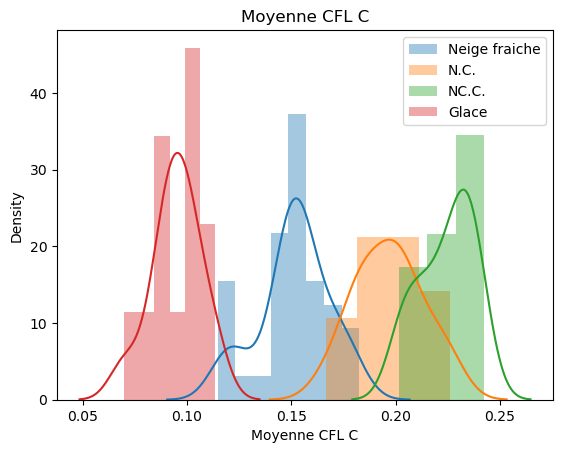

In [173]:
#sns.distplot(v['Moyenne CFL C'],label="verglas")
sns.distplot(nf['Moyenne CFL C'],label='Neige fraiche')
sns.distplot(nc['Moyenne CFL C'],label='N.C.')
sns.distplot(ncc['Moyenne CFL C'],label='NC.C.')
sns.distplot(g['Moyenne CFL C'],label='Glace')
#sns.distplot(s['Moyenne CFL C'],label='SLUSH')

plt.title('Moyenne CFL C')
plt.legend()
plt.show()

Apres preparation de cette base de données, de la figure ci-dessus, on peut dire que le CFL C classifie bien les differents contaminants

Pour cette partie de donnée on va appliqué le modele du random forest classifier, car dans ce cas, c'est le modele le modele le plus adaptéé, vue un nombre faible d'observation (le modele XGBoost non adapté) et des classes multimodales non binaires.
Pour le modele de regression logistique, certes il est donne une interpretabilité mais en meme temps une performance faible dans le cas d'une classification multimodale, ce probleme va etre eminenment observable dans la classification multivariée


In [174]:
# Split the data into training and test sets

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=64)
    
# Initialize and fit the Random Forest model
rf = RandomForestClassifier(n_estimators=200,min_samples_split = 4, class_weight='balanced', random_state=42)
rf.fit(X_train, y_train)
    
# Make predictions with Random Forest
y_pred_rf = rf.predict(X_test)
    
# Print classification report for Random Forest
print('\nClassification Report (Random Forest):')
print(classification_report(y_test, y_pred_rf))



Classification Report (Random Forest):
               precision    recall  f1-score   support

        Glace       1.00      1.00      1.00         2
         N.C.       0.60      0.75      0.67         4
        NC.C.       0.80      1.00      0.89         4
Neige fraiche       1.00      0.75      0.86         8

     accuracy                           0.83        18
    macro avg       0.85      0.88      0.85        18
 weighted avg       0.87      0.83      0.84        18



## Interpretabilité

On a vue que le modele precedent a montré un bonne performance, dans cette partie on va essayé de visualisé les predictions des classes dans un tableau des pedictions et un graphe, facilitant ainsi une prdiction rapide de la classe du contaminant à partir de sa valeur du CFL C

In [175]:
y_proba_rf = rf.predict_proba(X)
y_predict = rf.predict(X)
# Create a DataFrame with the CFL C values, true labels, and predicted probabilities
results_df = pd.DataFrame(X, columns=['Moyenne CFL C'])
results_df['True Label'] = y
results_df['Predected Label'] = y_predict
results_df = results_df.join(pd.DataFrame(y_proba_rf, columns=rf.classes_))
# Define the number of bins for the CFL C variable
num_bins = 10

# Assign each CFL C value to a bin
results_df['CFL C Interval'] = pd.cut(results_df['Moyenne CFL C'], bins=num_bins)

# Calculate average probabilities for each bin
interval_probs = results_df.groupby('CFL C Interval')[['Glace', "N.C.", "NC.C.", "Neige fraiche"]].mean()



# print(interval_probs)
results_df

,Moyenne CFL C,True Label,Predected Label,Glace,N.C.,NC.C.,Neige fraiche,CFL C Interval
0,0.11,Glace,Glace,0.62,0.00,0.00,0.38,"(0.104, 0.122]"
1,0.16,Neige fraiche,Neige fraiche,0.00,0.00,0.00,1.00,"(0.139, 0.156]"
2,0.18,N.C.,N.C.,0.00,0.84,0.00,0.16,"(0.173, 0.191]"
3,0.17,N.C.,N.C.,0.00,0.52,0.00,0.48,"(0.156, 0.173]"
4,0.19,N.C.,N.C.,0.00,0.92,0.00,0.07,"(0.173, 0.191]"
5,0.18,Neige fraiche,Neige fraiche,0.00,0.49,0.00,0.51,"(0.173, 0.191]"
6,0.15,Neige fraiche,Neige fraiche,0.00,0.00,0.00,1.00,"(0.139, 0.156]"
7,0.15,Neige fraiche,Neige fraiche,0.00,0.00,0.00,1.00,"(0.139, 0.156]"
8,0.22,N.C.,NC.C.,0.00,0.48,0.52,0.00,"(0.208, 0.225]"
9,0.17,Neige fraiche,Neige fraiche,0.00,0.49,0.00,0.51,"(0.156, 0.173]"


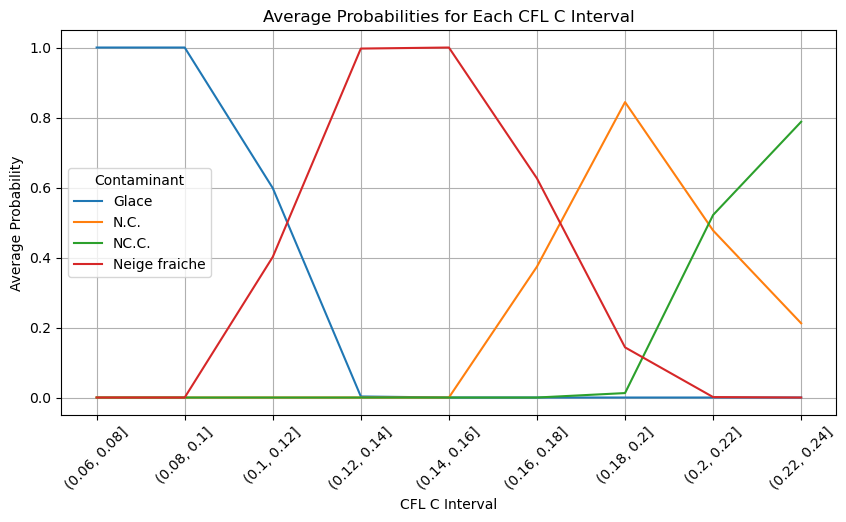

,Glace,N.C.,NC.C.,Neige fraiche,True Label,Predicted Label
CFL C Interval,,,,,,
"(0.06, 0.08]",1.00,0.00,0.00,0.00,Glace,Glace
"(0.08, 0.1]",1.00,0.00,0.00,0.00,Glace,Glace
"(0.1, 0.12]",0.60,0.00,0.00,0.40,Glace,Glace
"(0.12, 0.14]",0.00,0.00,0.00,1.00,Neige fraiche,Neige fraiche
"(0.14, 0.16]",0.00,0.00,0.00,1.00,Neige fraiche,Neige fraiche
"(0.16, 0.18]",0.00,0.37,0.00,0.63,Neige fraiche,Neige fraiche
"(0.18, 0.2]",0.00,0.84,0.01,0.14,N.C.,N.C.
"(0.2, 0.22]",0.00,0.48,0.52,0.00,N.C.,NC.C.
"(0.22, 0.24]",0.00,0.21,0.79,0.00,NC.C.,NC.C.


In [176]:
y_proba_rf = rf.predict_proba(X)

# Create a DataFrame with the CFL C values, true labels, and predicted probabilities
results_df = pd.DataFrame(X, columns=['Moyenne CFL C'])
results_df['True Label'] = y
results_df = results_df.join(pd.DataFrame(y_proba_rf, columns=rf.classes_))

# Calculate predicted labels based on the highest probability
results_df['Predicted Label'] = rf.predict(X)

# Define the number of bins for the CFL C variable
bin_edges = np.arange(0.06, 0.25, 0.02)

# Assign each CFL C value to a bin
results_df['CFL C Interval'] = pd.cut(results_df['Moyenne CFL C'], bins=bin_edges)

# Calculate average probabilities for each bin and include true and predicted labels
interval_probs = results_df.groupby('CFL C Interval')[['Glace', "N.C.", "NC.C.", "Neige fraiche"]].mean()

# Add true and predicted labels for each interval (count of true and predicted labels per interval)
interval_counts = results_df.groupby('CFL C Interval')[['True Label', 'Predicted Label']].agg(lambda x: x.value_counts().index[0])

# Merge average probabilities with the counts of true and predicted labels
interval_probs = interval_probs.join(interval_counts)

# Plot the average probabilities for each interval
plt.figure(figsize=(10, 5))
for class_label in rf.classes_:
    plt.plot(interval_probs.index.astype(str), interval_probs[class_label], label=class_label)

plt.xlabel('CFL C Interval')
plt.ylabel('Average Probability')
plt.title('Average Probabilities for Each CFL C Interval')
plt.legend(title='Contaminant')
plt.xticks(rotation=45)
plt.grid()
plt.show()
interval_probs

En descritisant le CFLC on a à peu pres, un modele parfait.

On peut visualiser egalement la probabilitée exacte d'appartenace pour chaque valeur du CFLC à un contaminant donnée 

In [177]:
# results_df

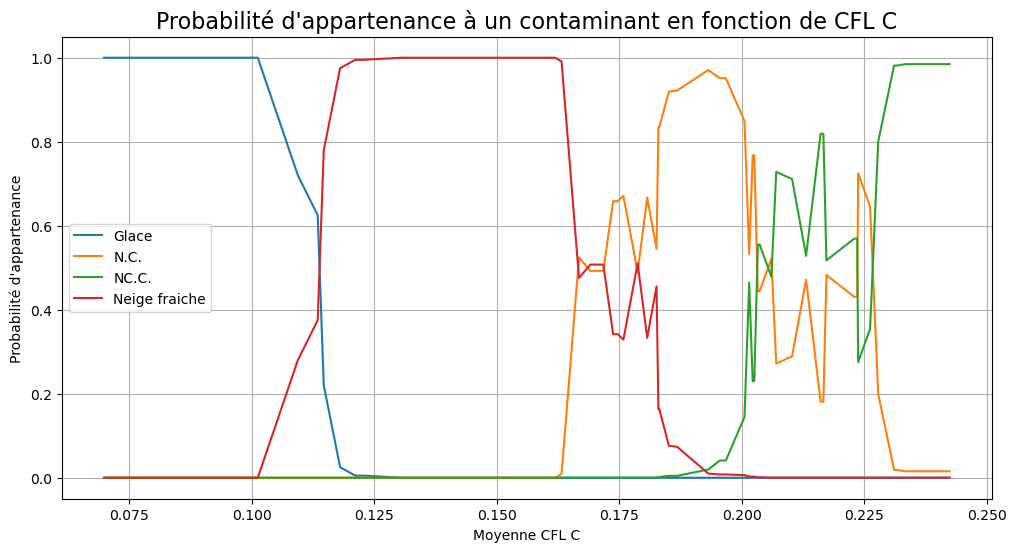

In [178]:
plt.figure(figsize=(12, 6))

a = results_df.sort_values(["Moyenne CFL C"])
plt.plot(a['Moyenne CFL C'], a['Glace'], label='Glace', linewidth=1.5)
plt.plot(a['Moyenne CFL C'], a['N.C.'], label='N.C.', linewidth=1.5)
plt.plot(a['Moyenne CFL C'], a['NC.C.'], label='NC.C.', linewidth=1.5)
plt.plot(a['Moyenne CFL C'], a['Neige fraiche'], label='Neige fraiche', linewidth=1.5)

# Set labels and title
plt.xlabel('Moyenne CFL C')
plt.ylabel('Probabilité d\'appartenance')
plt.title('Probabilité d\'appartenance à un contaminant en fonction de CFL C', fontsize=16)

# Add grid and legend
plt.grid(True)
plt.legend()

# Show plot
plt.show()